# Run artworks example

This notebook implements a quick inference on the labeled examples. Since the examples source code are now stored in a JSON file, and not into seperate files, we have this notebook to not interfeer with he code that will be used to run on the new source code files.

## Imports, configs and read data

In [1]:
import json
import yaml
from Model import LLM_Model
from Prompts import *
from collections import Counter
import matplotlib.pyplot as plt

def get_prompt_template(prompt_version):
    return globals()[prompt_version].template

def count_labels(examples, classification_key):
    counter = Counter()

    for ex in examples:
        classification = ex.get(classification_key, {})

        for dimension, labels in classification.items():
            for label in labels:
                counter[f"{dimension}_{label}"] += 1

    return dict(counter)


def count_all_labels(examples):
    return {
        "classification": count_labels(examples, "classification"),
        "predicted_classification": count_labels(examples, "predicted_classification"),
    }

def count_labels(examples, classification_key):
    counter = Counter()

    for ex in examples:
        classification = ex.get(classification_key, {})
        for dimension, labels in classification.items():
            for label in labels:
                counter[f"{dimension}_{label}"] += 1

    return counter


def plot_all_distributions(examples):
    true_counts = count_labels(examples, "classification")
    pred_counts = count_labels(examples, "predicted_classification")

    all_labels = sorted(set(true_counts) | set(pred_counts))
    x = range(len(all_labels))
    width = 0.4

    plt.figure(figsize=(12, 5))
    plt.bar([i - width/2 for i in x], [true_counts.get(label, 0) for label in all_labels], width=width, label="classification")
    plt.bar([i + width/2 for i in x], [pred_counts.get(label, 0) for label in all_labels], width=width, label="predicted_classification")

    plt.xticks(x, all_labels, rotation=45, ha="right")
    plt.ylabel("Count")
    plt.title("Classification vs Predicted Classification")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_distributions_by_dimension(examples):
    true_counts = count_labels(examples, "classification")
    pred_counts = count_labels(examples, "predicted_classification")

    for dimension in ["entities", "interaction", "outcome"]:
        labels = sorted([
            key.split("_", 1)[1]
            for key in set(true_counts) | set(pred_counts)
            if key.startswith(f"{dimension}_")
        ])

        x = range(len(labels))
        width = 0.4

        plt.figure(figsize=(8, 4)) 
        plt.bar([i - width/2 for i in x], [true_counts.get(f"{dimension}_{label}", 0) for label in labels], width=width, label="classification")
        plt.bar([i + width/2 for i in x], [pred_counts.get(f"{dimension}_{label}", 0) for label in labels], width=width, label="predicted_classification")

        plt.xticks(x, labels, rotation=45, ha="right")
        plt.ylabel("Count")
        plt.title(f"{dimension}: classification vs predicted")
        plt.legend()
        plt.tight_layout()
        plt.show()

In [2]:
# Read configs
print("Configs...")
with open("../config.yml", "r") as f:
    configs = yaml.safe_load(f)

config_mode = configs["chosen_config"]['config_mode']
model = configs["chosen_config"]["model"]

Configs...


In [3]:
# Read examples
with open("../examples/artworks_new_classif.json") as f:
    examples = json.load(f)

# Print one examples
# examples[0]

In [4]:
llm_model = LLM_Model(
    model_name=configs[model]['model_name'],
    base_url=configs[model]['base_url'],
    system_prompt=configs[model]['system_prompt']
)

## Inference

In [5]:
prompt_version = "PROMPT_5"
prompt = get_prompt_template(prompt_version)

print("Using this prompt:\n", prompt)

for i, artwork in enumerate(examples):
    # Read src code
    art_src_code = artwork['metadata']['content']

    # Pass it to LLM
    predicted_labels = llm_model.get_labels(
        prompt_template=prompt, 
        art_src_code=art_src_code, 
        system_prompt=llm_model.system_prompt
    )
    # print("Actual labels:", artwork['classification'])
    # print("Predicted labels:", predicted_labels)

    # Add prediction back to the json
    examples[i]["predicted_classification"] = predicted_labels
    

Using this prompt:
 You are an expert in generative art in p5.js, and you are going to analyse a source code of a generative artwork in p5.js and output tags in JSON.

The ONLY dimensions and allowed tags are:

---

entities (0+ tags):

- "processed_audio" // uses preexisting audio material, such as mp3, wav, or MIDI files, as part of the artwork
- "processed_image" // uses preexisting visual material, such as image or video files, as part of the artwork
- "processed_text" // uses preexisting textual material, such as text or code files, as part of the artwork
- "randomness"

interaction (exactly 1):

- "yes" // the artwork includes interaction, such as mouse, keyboard, MIDI, mic, camera, motion sensor, lidar. Reading data files, streams, remote data, or web APIs also counts as interactions.
- "no" // if the artwork does not include interactions (or if the only interaction is to save images)

outcome (≥1 modality + 1 time tag):

- "visual" // Add "visual" modality whenever the code dra

## Data Viz

In [6]:
results = count_all_labels(examples)

results["classification"]
results["predicted_classification"]

Counter({'outcome_visual': 74,
         'outcome_time_based': 57,
         'interaction_no': 47,
         'interaction_yes': 27,
         'outcome_static': 17,
         'entities_randomness': 16,
         'entities_processed_image': 12,
         'outcome_auditory': 9,
         'entities_processed_audio': 7,
         'entities_processed_text': 4,
         'outcome_text': 2,
         'entities_processed_font': 1,
         'entities_processed_json': 1})

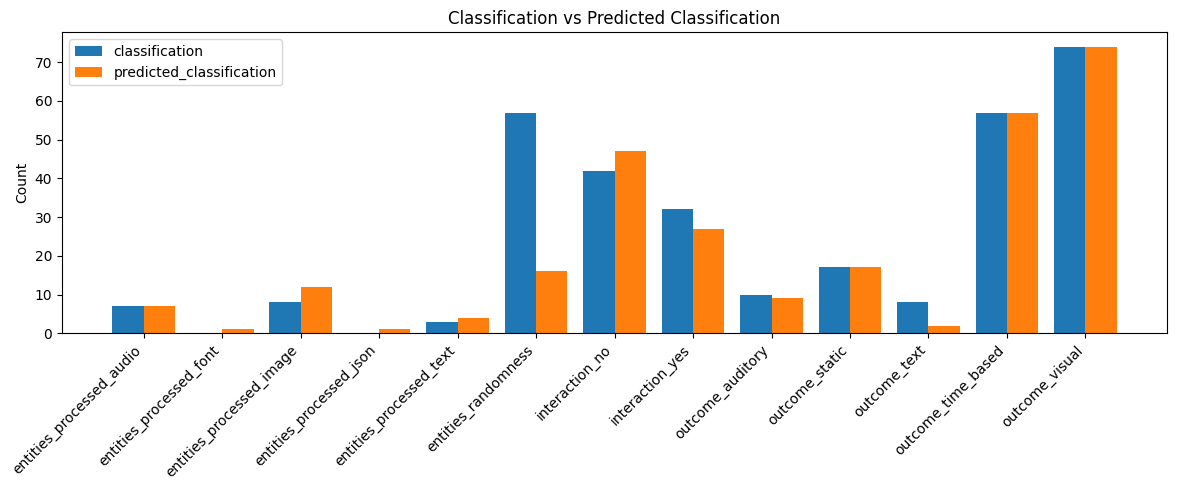

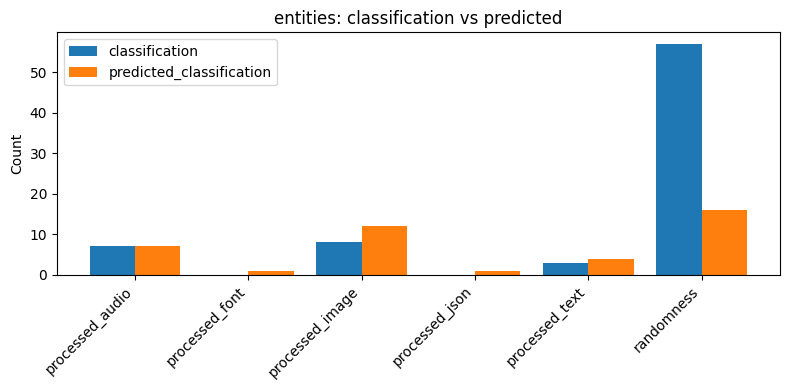

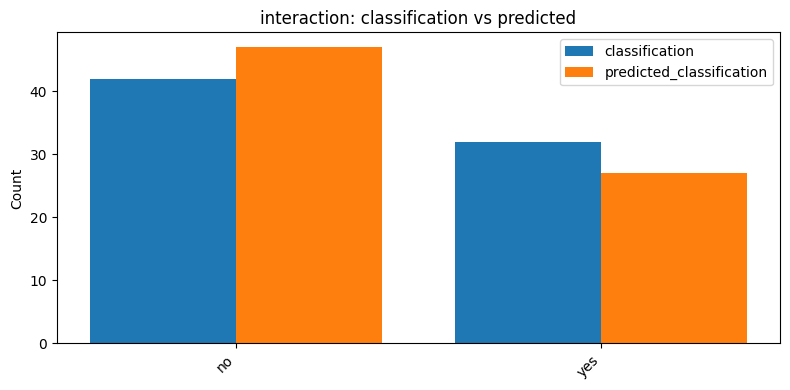

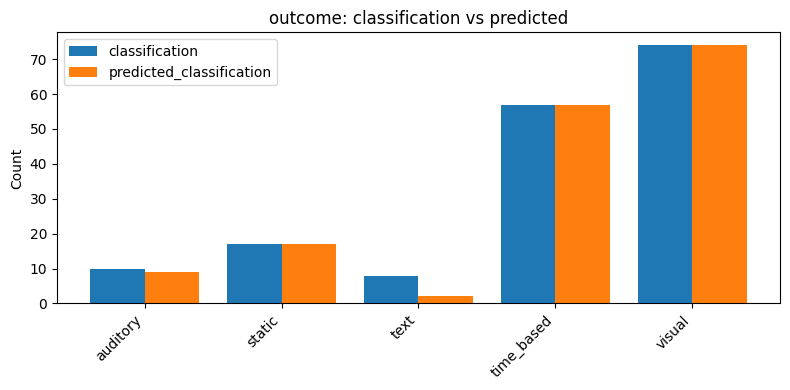

In [7]:
plot_all_distributions(examples)
plot_distributions_by_dimension(examples)

In [8]:
with open("examples.json", "w", encoding="utf-8") as f:
    json.dump(examples, f, ensure_ascii=False, indent=2)

In [9]:
examples

[{'id': 'A1',
  'title': 'black&white_rotate',
  'artist': 'Benoit Baudry',
  'repoUrl': 'None',
  'year': '2020',
  'classification': {'entities': ['randomness'],
   'interaction': ['no'],
   'outcome': ['visual', 'time_based']},
  'description': 'A generative landscape created using Perlin noise.',
  'llm_notes': 'Relies on Perlin noise to produce smooth organic shapes resembling a landscape.',
  'metadata': {'file_name': 'black&white_rotate',
   'extension': '.js',
   'content': 'let canvasWidth = 800;\nlet canvasHeight = 800;\nlet topLayer;\nlet bottomLayer;\nlet startX = -canvasWidth; // Start off-screen\nlet weightDifference;\nlet blackWeight;\nlet whiteWeight;\nlet maskGraphics; \n\n\nfunction setup() {\n  createCanvas(canvasWidth, canvasHeight);\n\n  topLayer = createGraphics(canvasWidth, canvasHeight); \n  bottomLayer = createGraphics(canvasWidth, canvasHeight); \n\n  weightDifference = random(-5, 5);\n  blackWeight = random(5, 20);\n  whiteWeight = blackWeight + weightDiffere